# TECH 405 – Week 5 RNN Hackathon

## LSTM Classification on the sklearn Digits Dataset

**Dataset:** sklearn Digits Dataset  
**Task:** Handwritten digit classification (10 classes)  
**Baseline Accuracy:** 10%  
**Target Accuracy:** 93%

The aim of this experiment is to classify handwritten digits using an LSTM neural network. Each 8 × 8 image is treated as a sequence of 8 rows, where each row represents one time step containing 8 pixel features.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Dataset and Sequence Representation

The sklearn Digits dataset contains 1,797 grayscale images of handwritten digits from 0 to 9. Each image has a resolution of 8 × 8 pixels.

For the LSTM model, each image is interpreted as a sequence:

- **Sequence length:** 8
- **Features per time step:** 8
- **Output classes:** 10

Each row of the image is processed as one time step by the LSTM. This makes the dataset suitable for a sequence model because the network processes the rows in order and learns relationships between pixel patterns across the image.


In [20]:
digits = load_digits()

X = digits.images
y = digits.target

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", np.unique(y))

Dataset shape: (1797, 8, 8)
Labels shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


**Figure 1 – Dataset shape and class information (Snapshot 1):**  
The sklearn Digits dataset contains 1,797 grayscale images of size 8 × 8 pixels across 10 classes. Each image is treated as a sequence of 8 time steps with 8 features per step.


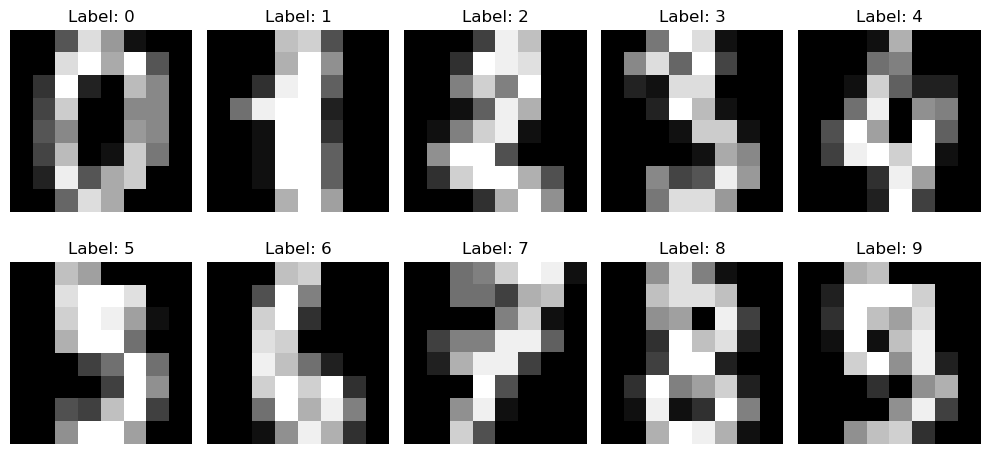

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Data Preprocessing

The original pixel values range from 0 to 16. They are normalized to the range 0 to 1 by dividing by 16. Normalization keeps the input values on a consistent scale and helps the neural network train more effectively.


In [22]:
print("Before normalization:")
print("Min:", X.min())
print("Max:", X.max())

X = X.astype(np.float32) / 16.0

print("\nAfter normalization:")
print("Min:", X.min())
print("Max:", X.max())

Before normalization:
Min: 0.0
Max: 16.0

After normalization:
Min: 0.0
Max: 1.0


## Fixed 80/20 Train–Test Split

The assignment requires a fixed 80/20 split. A fixed `random_state=42` is used so that the same samples are assigned to the training and test sets every time the notebook is run. Stratification is also used so that the class distribution remains balanced.

The test set is kept untouched during model development. A validation set is created only from the training portion and is used for model selection and hyperparameter comparison.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1437, 8, 8)
Test shape: (360, 8, 8)


In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (1149, 8, 8)
Validation: (288, 8, 8)
Test: (360, 8, 8)


In [25]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [26]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 36
Validation batches: 9
Test batches: 12


## LSTM Model

The classifier uses a two-layer LSTM with 128 hidden units. The LSTM receives each digit as an 8-step sequence, where each time step contains 8 pixel features. The output from the final time step is passed to a fully connected `nn.Linear` layer that predicts one of the 10 digit classes.

This follows the required architecture from the lectures: **`nn.LSTM → nn.Linear`**. No pretrained model is used.


In [27]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size=8,
        hidden_size=128,
        num_layers=2,
        num_classes=10,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        last_output = output[:, -1, :]

        output = self.fc(last_output)

        return output


model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(8, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


## Training Configuration

The model is trained using:

- **Loss function:** CrossEntropyLoss
- **Optimizer:** Adam
- **Learning rate:** 0.001
- **Batch size:** 32
- **Epochs:** 50

The training set is used to update the model weights, while validation accuracy is monitored separately. The test set is not used for tuning.


In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [29]:
EPOCHS = 50

train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    # Validation
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    val_accuracy = correct / total

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy*100:.2f}%"
    )

Epoch 1/50 | Loss: 2.2603 | Validation Accuracy: 29.86%
Epoch 2/50 | Loss: 1.6608 | Validation Accuracy: 57.64%
Epoch 3/50 | Loss: 1.1542 | Validation Accuracy: 71.18%
Epoch 4/50 | Loss: 0.9229 | Validation Accuracy: 71.88%
Epoch 5/50 | Loss: 0.7338 | Validation Accuracy: 80.56%
Epoch 6/50 | Loss: 0.6073 | Validation Accuracy: 85.07%
Epoch 7/50 | Loss: 0.5166 | Validation Accuracy: 87.50%
Epoch 8/50 | Loss: 0.4427 | Validation Accuracy: 88.19%
Epoch 9/50 | Loss: 0.3787 | Validation Accuracy: 88.19%
Epoch 10/50 | Loss: 0.3396 | Validation Accuracy: 89.58%
Epoch 11/50 | Loss: 0.3039 | Validation Accuracy: 89.58%
Epoch 12/50 | Loss: 0.2727 | Validation Accuracy: 90.97%
Epoch 13/50 | Loss: 0.2218 | Validation Accuracy: 92.01%
Epoch 14/50 | Loss: 0.2043 | Validation Accuracy: 90.97%
Epoch 15/50 | Loss: 0.1828 | Validation Accuracy: 90.97%
Epoch 16/50 | Loss: 0.1714 | Validation Accuracy: 94.44%
Epoch 17/50 | Loss: 0.1490 | Validation Accuracy: 92.71%
Epoch 18/50 | Loss: 0.1376 | Validation 

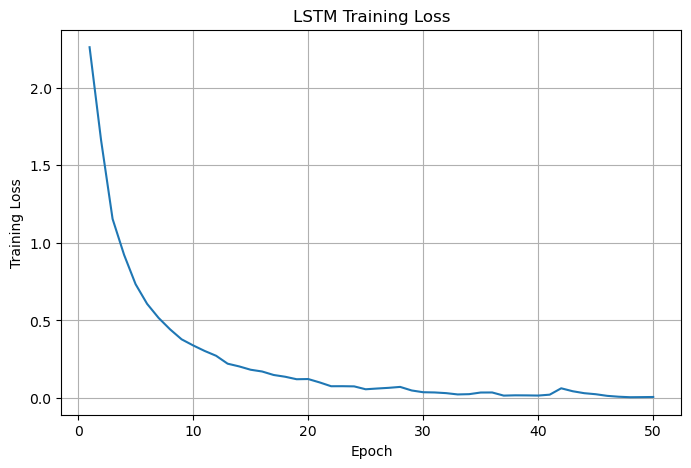

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM Training Loss")
plt.grid(True)

plt.show()

**Figure 3 – Training loss (Snapshot 3):**  
The training loss decreases substantially across the 50 epochs, showing that the LSTM progressively learned useful sequential patterns from the handwritten digit images.


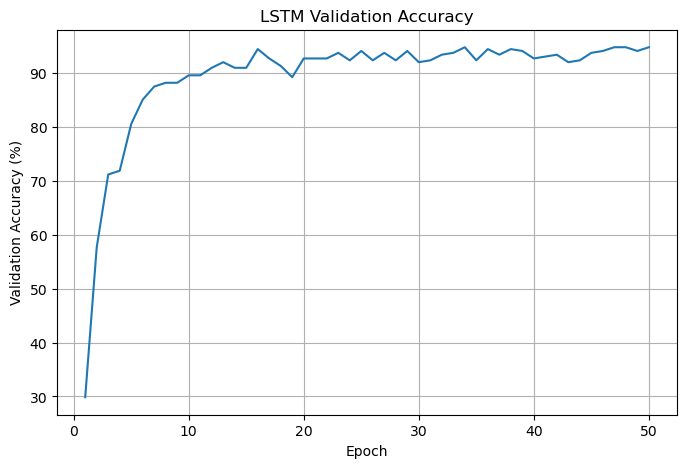

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    np.array(val_accuracies) * 100
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("LSTM Validation Accuracy")
plt.grid(True)

plt.show()

## Hyperparameter Experiments

Three LSTM configurations were compared using the **validation set only**. The test set was not used during these experiments.

To make the comparison fair, each configuration is trained for 30 epochs with the same learning rate and batch size. The final model uses the strongest configuration and is then trained for 50 epochs in the main training section above.


In [32]:
# Hyperparameter experiments using VALIDATION data only
# The test set is not used here.

class ExperimentLSTM(nn.Module):
    def __init__(self, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=8,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 10)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        return self.fc(output[:, -1, :])


def run_experiment(hidden_size, num_layers, lr=0.001, epochs=30):
    # Fixed seed for a reproducible comparison
    torch.manual_seed(42)

    experiment_model = ExperimentLSTM(
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=0.2 if num_layers > 1 else 0.0
    ).to(device)

    experiment_optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=lr
    )

    experiment_criterion = nn.CrossEntropyLoss()

    best_val_accuracy = 0.0

    for epoch in range(epochs):
        experiment_model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            experiment_optimizer.zero_grad()

            outputs = experiment_model(X_batch)
            loss = experiment_criterion(outputs, y_batch)

            loss.backward()
            experiment_optimizer.step()

        # Validation only
        experiment_model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = experiment_model(X_batch)
                predicted = outputs.argmax(dim=1)

                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)

        val_accuracy = correct / total
        best_val_accuracy = max(best_val_accuracy, val_accuracy)

    return best_val_accuracy * 100


experiment_settings = [
    {"hidden_size": 32,  "num_layers": 1, "lr": 0.001},
    {"hidden_size": 64,  "num_layers": 1, "lr": 0.001},
    {"hidden_size": 128, "num_layers": 2, "lr": 0.001},
]

experiment_results = []

for i, config in enumerate(experiment_settings, start=1):
    best_val = run_experiment(**config)

    experiment_results.append({
        "Experiment": i,
        "Hidden Size": config["hidden_size"],
        "LSTM Layers": config["num_layers"],
        "Learning Rate": config["lr"],
        "Best Validation Accuracy (%)": round(best_val, 2)
    })

for result in experiment_results:
    print(result)


{'Experiment': 1, 'Hidden Size': 32, 'LSTM Layers': 1, 'Learning Rate': 0.001, 'Best Validation Accuracy (%)': 94.1}
{'Experiment': 2, 'Hidden Size': 64, 'LSTM Layers': 1, 'Learning Rate': 0.001, 'Best Validation Accuracy (%)': 94.44}
{'Experiment': 3, 'Hidden Size': 128, 'LSTM Layers': 2, 'Learning Rate': 0.001, 'Best Validation Accuracy (%)': 94.44}


## Final Test Evaluation

After model development was complete, the selected LSTM was evaluated on the untouched 20% test set. This is the only test accuracy reported for the final model.


In [33]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 96.39%


## Confusion Matrix

The confusion matrix shows the relationship between the true digit labels and the model's predictions. Most predictions lie on the main diagonal, indicating that the majority of samples were classified correctly.


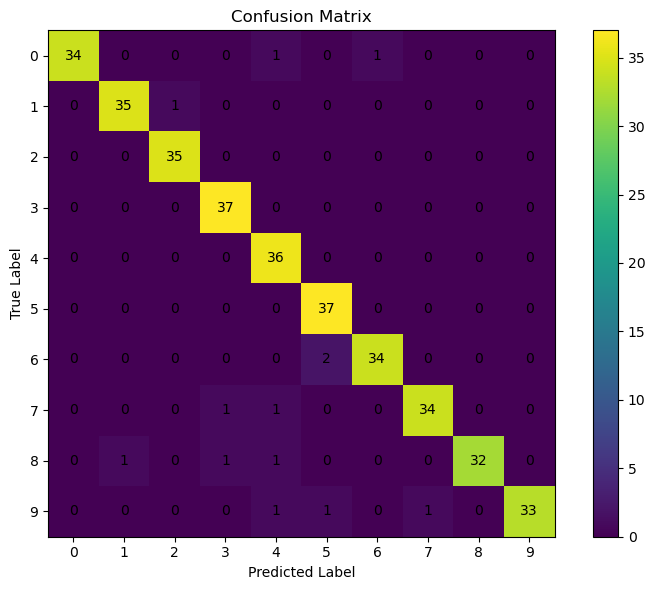

In [34]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## Precision, Recall and F1-score

The classification report provides class-wise precision, recall, and F1-score in addition to overall accuracy. The model performs strongly across all 10 classes. Digit 5 achieved perfect precision, recall, and F1-score on this test split, while digit 9 had the lowest recall and was therefore one of the more difficult classes for the model.


In [35]:
print(
    classification_report(
        all_labels,
        all_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.9444    0.9714        36
           1     0.9722    0.9722    0.9722        36
           2     0.9722    1.0000    0.9859        35
           3     0.9487    1.0000    0.9737        37
           4     0.9000    1.0000    0.9474        36
           5     0.9250    1.0000    0.9610        37
           6     0.9714    0.9444    0.9577        36
           7     0.9714    0.9444    0.9577        36
           8     1.0000    0.9143    0.9552        35
           9     1.0000    0.9167    0.9565        36

    accuracy                         0.9639       360
   macro avg     0.9661    0.9637    0.9639       360
weighted avg     0.9658    0.9639    0.9639       360



## Baseline and Target Comparison

The majority-class baseline for the Digits dataset is 10%, while the full-marks target is 93%. The final LSTM result is compared with both values below.


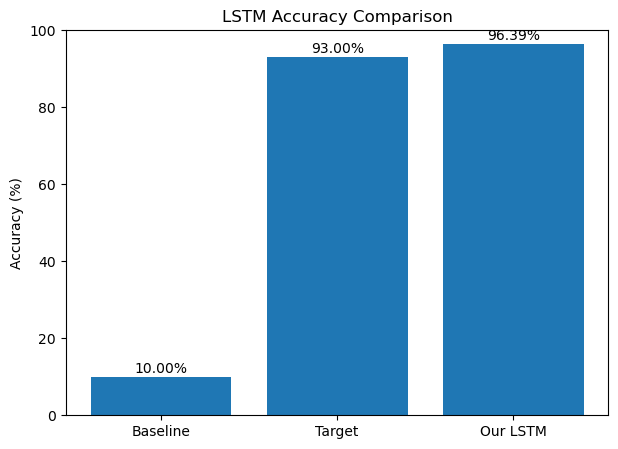

Baseline: 10%
Target: 93%
Our Test Accuracy: 96.39%


In [36]:
baseline = 10
target = 93
our_accuracy = test_accuracy * 100

labels = ["Baseline", "Target", "Our LSTM"]
values = [baseline, target, our_accuracy]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.ylabel("Accuracy (%)")
plt.title("LSTM Accuracy Comparison")
plt.ylim(0, 100)

for i, value in enumerate(values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

print(f"Baseline: {baseline}%")
print(f"Target: {target}%")
print(f"Our Test Accuracy: {our_accuracy:.2f}%")